<a href="https://colab.research.google.com/github/sasitharanDSAI/task-7/blob/main/Sales_Summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to SQLite database
conn = sqlite3.connect('sales_data.db')



#SQL query to get total quantity and revenue per product

In [27]:
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC
LIMIT 10
"""
df = pd.read_sql_query(query, conn)
print(df)

                                             product  total_qty    revenue
0              Canon imageCLASS 2200 Advanced Copier         20  61599.824
1  Fellowes PB500 Electric Punch Plastic Comb Bin...         31  27453.384
2  Cisco TelePresence System EX90 Videoconferenci...          6  22638.480
3       HON 5400 Series Task Chairs for Big and Tall         39  21870.576
4         GBC DocuBind TL300 Electric Binding System         37  19823.479
5   GBC Ibimaster 500 Manual ProClick Binding System         48  19024.500
6               Hewlett Packard LaserJet 3310 Copier         38  18839.686
7  HP Designjet T520 Inkjet Large Format Printer ...         12  18374.895
8          GBC DocuBind P400 Electric Binding System         27  17965.068
9        High Speed Automatic Electric Letter Opener         11  17030.312


# Plot the top 10 products by revenue with labels

<ipython-input-34-9d61811e6b2d>:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


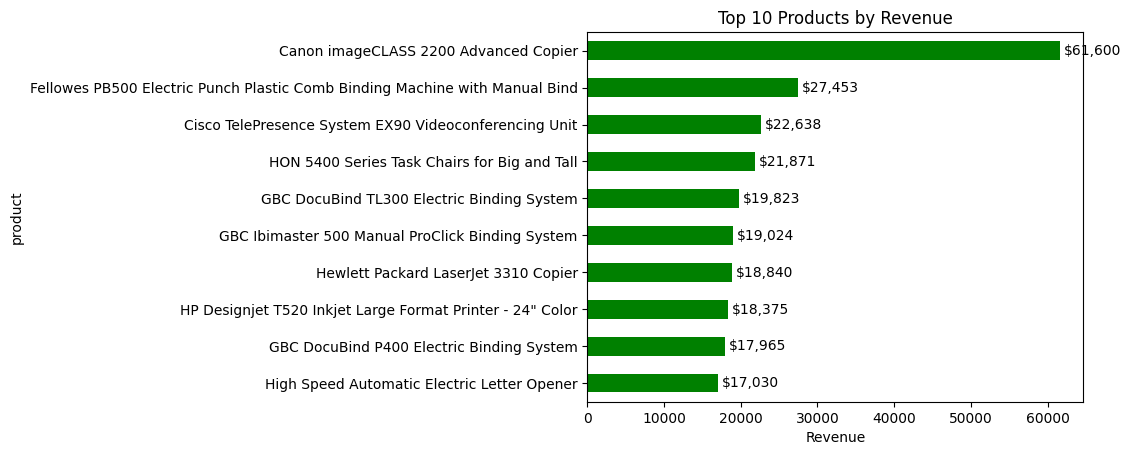

In [34]:
df.plot(kind='barh', x='product', y='revenue', color='green', legend=False)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
for i, v in enumerate(df['revenue']):
    plt.text(v + 500, i, f"${v:,.0f}", va='center')
plt.tight_layout()
plt.savefig("sales_chart_top10_labeled.png")
plt.show()


#  Total revenue across all products

In [29]:
query_total = "SELECT SUM(quantity * price) AS total_revenue FROM sales"
total_revenue = pd.read_sql_query(query_total, conn).iloc[0, 0]

conn.close()

# Plot Top 10 revenue products

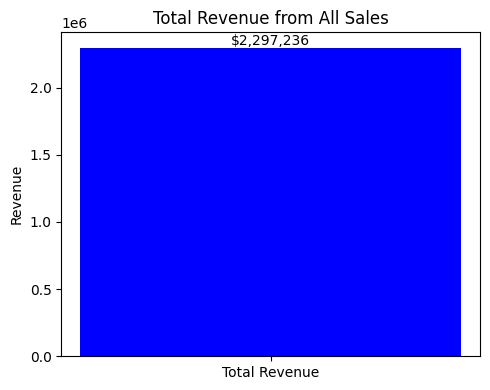

In [31]:
plt.figure(figsize=(5, 4))
plt.bar(['Total Revenue'], [total_revenue], color='blue')
plt.title('Total Revenue from All Sales')
plt.ylabel('Revenue')
plt.text(0, total_revenue + total_revenue * 0.01, f"${total_revenue:,.0f}", ha='center')
plt.tight_layout()
plt.savefig('sales_chart_total.png')
plt.show()